In [34]:
import os

# Evitar error en ultralytics
os.environ["MKL_SERVICE_FORCE_INTEL"] = "1"
os.environ["MKL_THREADING_LAYER"] = "GNU"

import glob
from collections import defaultdict
import yaml
from IPython.display import Video, display

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import matplotlib.gridspec as gridspec
import seaborn as sns

from ultralytics import YOLO, RTDETR

# Parche para compatibilidad de motmetrics con NumPy 2.0+
if not hasattr(np, 'asfarray'):
    np.asfarray = lambda a, dtype=float, order='C': np.asarray(a, dtype=dtype, order=order)

import motmetrics as mm
from trackers.eval.hota import compute_hota_metrics


# Detección de Objetos

## Descripción Dataset

### Configuración

In [35]:
DATASET_DIR = "AnimalTrack"
CATEGORIES = ["horse", "pig", "penguin"]
ANALYSIS_DIR = "dataset_analysis"
ULTRALYTICS_DIR = "ultralytics_dataset"
os.makedirs(ANALYSIS_DIR, exist_ok=True)
os.makedirs(ULTRALYTICS_DIR, exist_ok=True)

np.random.seed(42)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

CATEGORY_COLORS = {
    "horse": "#1f77b4",
    "pig": "#ff7f0e",
    "penguin": "#2ca02c"
}

### Cargar y Parsear Groud Truths

In [36]:
all_data = []  

for category in CATEGORIES:
    gt_dir = os.path.join(DATASET_DIR, category, "gt")
    gt_files = sorted(glob.glob(os.path.join(gt_dir, "*.txt")))[:5] # solo los primeros 5 videos

    for gt_file in gt_files:
        video_name = os.path.basename(gt_file).replace("_gt.txt", "")
        with open(gt_file, "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) >= 7:
                    frame_id = int(parts[0])
                    obj_id = int(parts[1])
                    x = float(parts[2])
                    y = float(parts[3])
                    w = float(parts[4])
                    h = float(parts[5])
                    flag = int(parts[6])
                    class_id = int(parts[7]) if len(parts) > 7 else -1
                    all_data.append({
                        "category": category,
                        "video": video_name,
                        "frame_id": frame_id,
                        "object_id": obj_id,
                        "x": x, "y": y, "w": w, "h": h,
                        "flag": flag,
                        "class_id": class_id
                    })

df = pd.DataFrame(all_data)
df["category"] = pd.Categorical(df["category"], categories=CATEGORIES, ordered=True)

### Frames Por Video

In [37]:
# Contar frames unicos por video
frames_per_video = df.groupby(["category", "video"])["frame_id"].nunique().reset_index()
frames_per_video.columns = ["Category", "Video", "Num_Frames"]
frames_per_video = frames_per_video.sort_values(["Category", "Video"])

print("\n--- Frames por Video ---")
print(frames_per_video.to_string(index=False))

# Resumen por categoria
frames_summary = frames_per_video.groupby("Category")["Num_Frames"].agg(
    ["count", "sum", "mean", "min", "max"]
).reset_index()
frames_summary.columns = ["Category", "Num Videos", "Total Frames", "Avg Frames", "Min Frames", "Max Frames"]
frames_summary["Avg Frames"] = frames_summary["Avg Frames"].round(1)

print("\n--- Resumen por Categoria ---")
print(frames_summary.to_string(index=False))
print(f"\nFrames totales: {frames_per_video['Num_Frames'].sum():,}")

# Frames por Video
fig, ax = plt.subplots(figsize=(14, 6))
colors = [CATEGORY_COLORS[cat] for cat in frames_per_video["Category"]]

bars = ax.bar(range(len(frames_per_video)), frames_per_video["Num_Frames"], color=colors, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(frames_per_video)))
ax.set_xticklabels(frames_per_video["Video"], rotation=45, ha="right", fontsize=10)
ax.set_xlabel("Video")
ax.set_ylabel("Numero de Frames")
ax.set_title("Numero de Frames por Video")

for bar, val in zip(bars, frames_per_video["Num_Frames"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=9)

legend_patches = [Patch(facecolor=CATEGORY_COLORS[c], label=c.capitalize()) for c in CATEGORIES]
ax.legend(handles=legend_patches, loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "frames_per_video.png"), dpi=150, bbox_inches='tight')
plt.close()

# Distribución de categorías
total_frames_per_cat = frames_per_video.groupby("Category")["Num_Frames"].sum()
colors_pie = [CATEGORY_COLORS[c] for c in total_frames_per_cat.index]
wedges, texts, autotexts = plt.pie(
    total_frames_per_cat, labels=[c.capitalize() for c in total_frames_per_cat.index],
    autopct='%1.1f%%', colors=colors_pie, startangle=90,
    textprops={'fontsize': 12}
)
plt.title("Distribución de frames por categoría")


plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "category_frames_distribution.png"), dpi=150, bbox_inches='tight')
plt.close()


--- Frames por Video ---
Category     Video  Num_Frames
   horse   horse_1         284
   horse   horse_2         310
   horse   horse_3        1434
   horse   horse_4         206
   horse   horse_5         325
     pig     pig_1         315
     pig     pig_2         312
     pig     pig_3         312
     pig     pig_4         274
     pig     pig_5         318
 penguin penguin_1         314
 penguin penguin_2         325
 penguin penguin_3         322
 penguin penguin_4         328
 penguin penguin_5         321

--- Resumen por Categoria ---
Category  Num Videos  Total Frames  Avg Frames  Min Frames  Max Frames
   horse           5          2559       511.8         206        1434
     pig           5          1531       306.2         274         318
 penguin           5          1610       322.0         314         328

Frames totales: 5,700


### Numero de detecciones por categoria


--- Detecciones por Categoria ---
Category  Total Detections
   horse             37732
     pig             32273
 penguin             26287

--- Detecciones por Video ---
category     video  Detections
   horse   horse_1        6653
   horse   horse_2        5815
   horse   horse_3       15930
   horse   horse_4        3731
   horse   horse_5        5603
     pig     pig_1        2623
     pig     pig_2       10854
     pig     pig_3        6761
     pig     pig_4        6567
     pig     pig_5        5468
 penguin penguin_1        4868
 penguin penguin_2        8901
 penguin penguin_3        2496
 penguin penguin_4        6290
 penguin penguin_5        3732

--- Objetos unicos por Video ---
Category     Video  Num_Objects
   horse   horse_1           50
   horse   horse_2           37
   horse   horse_3           68
   horse   horse_4           20
   horse   horse_5           20
     pig     pig_1           18
     pig     pig_2           57
     pig     pig_3           24
     pig

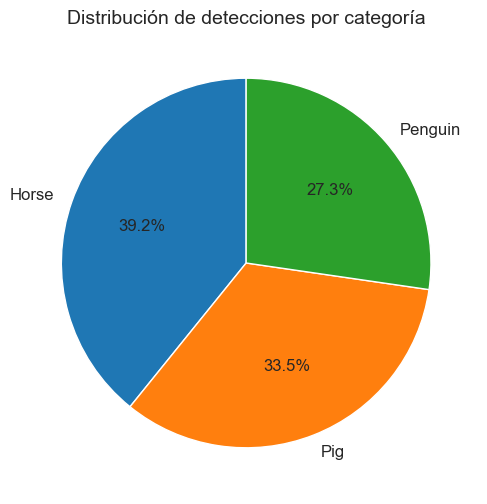

In [38]:

# Contar detecciones por categoria
detections_per_category = df.groupby("category").size().reset_index(name="Total_Detections")
detections_per_category.columns = ["Category", "Total Detections"]

# Objetos unicos por video
objects_per_video = df.groupby(["category", "video"])["object_id"].nunique().reset_index()
objects_per_video.columns = ["Category", "Video", "Num_Objects"]

# Detecciones por video
dets_per_video = df.groupby(["category", "video"]).size().reset_index(name="Detections")

print("\n--- Detecciones por Categoria ---")
print(detections_per_category.to_string(index=False))

print("\n--- Detecciones por Video ---")
print(dets_per_video.to_string(index=False))

print("\n--- Objetos unicos por Video ---")
print(objects_per_video.to_string(index=False))

# Resumen
total_summary = pd.DataFrame({
    "Category": CATEGORIES,
    "Total Detections": [df[df["category"] == c].shape[0] for c in CATEGORIES],
    "Total Unique Objects": [df[df["category"] == c]["object_id"].nunique() for c in CATEGORIES],
    "Avg Detections/Frame": [
        df[df["category"] == c].shape[0] / df[df["category"] == c]["frame_id"].nunique()
        for c in CATEGORIES
    ]
})
total_summary["Avg Detections/Frame"] = total_summary["Avg Detections/Frame"].round(2)

print("\n--- Resumen ---")
print(total_summary.to_string(index=False))

# Detecciones por video agrupadas por categoría
x_positions = []
x_labels = []
color_list = []
det_values = []
offset = 0

for cat in CATEGORIES:
    cat_data = dets_per_video[dets_per_video["category"] == cat]
    for _, row in cat_data.iterrows():
        x_positions.append(offset)
        x_labels.append(row["video"])
        color_list.append(CATEGORY_COLORS[cat])
        det_values.append(row["Detections"])
        offset += 1

bars2 = plt.bar(x_positions, det_values, color=color_list, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars2, det_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=9)

# Corrección en esta línea:
plt.xticks(x_positions, x_labels, rotation=45, ha="right", fontsize=8)

plt.ylabel("Numero de Detecciones")
plt.title("Detecciones por Video")
plt.legend(handles=legend_patches, loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "detections_per_video.png"), dpi=150, bbox_inches='tight')
plt.close()

# Distribución de categorías
total_dets_per_cat = dets_per_video.groupby("category")["Detections"].sum()
colors_pie = [CATEGORY_COLORS[c] for c in total_dets_per_cat.index]
wedges, texts, autotexts = plt.pie(
    total_dets_per_cat, labels=[c.capitalize() for c in total_dets_per_cat.index],
    autopct='%1.1f%%', colors=colors_pie, startangle=90,
    textprops={'fontsize': 12}
)
plt.title("Distribución de detecciones por categoría")
plt.savefig(os.path.join(ANALYSIS_DIR, "category_detections_distribution.png"), dpi=150, bbox_inches='tight')


### Preparación del Dataset

#### Split (train, val, test)

In [39]:
video_info = frames_per_video.copy()
video_info = video_info.sort_values(["Category", "Num_Frames"], ascending=[True, False]).reset_index(drop=True)

# Split por categoría
split_assignments = {}

for category in CATEGORIES:
    cat_videos = video_info[video_info["Category"] == category].copy()
    n_videos = len(cat_videos)

    # Indices del split
    video_list = cat_videos["Video"].tolist()
    frame_list = cat_videos["Num_Frames"].tolist()

    # Videos ordenados segun numero de frames (descendente)
    # Evita que se elijan los videos con pocos frames y quedarnos con pocos datos de entrenamiento
    sorted_indices = np.argsort(frame_list)[::-1]

    # Primeros ~60% para entrenamiento, ~20% para validacion y últimos ~20% para test (mínimo un video por conjunto)
    n_train = max(1, round(n_videos * 0.6))
    n_val = max(1, round(n_videos * 0.2))
    n_test = max(1, n_videos - n_train - n_val)

    # Ajustar si se han asignado demasiados videos al especificar el mínimo de 1
    if n_train + n_val + n_test > n_videos:
        n_train = n_videos - n_val - n_test

    for i, idx in enumerate(sorted_indices):
        video = video_list[idx]
        if i < n_train:
            split_assignments[video] = "train"
        elif i < n_train + n_val:
            split_assignments[video] = "val"
        else:
            split_assignments[video] = "test"

video_info["Split"] = video_info["Video"].map(split_assignments)

print("--- Split de Conjunto ---")
print(video_info[["Category", "Video", "Num_Frames", "Split"]].to_string(index=False))

# Estadisticas por split
print("\n--- Resumen de split---")
split_summary = video_info.groupby("Split").agg(
    Num_Videos=("Video", "count"),
    Total_Frames=("Num_Frames", "sum")
).reset_index()
split_summary["Frame %"] = (split_summary["Total_Frames"] / split_summary["Total_Frames"].sum() * 100).round(1)
split_summary = split_summary.sort_values("Split", key=lambda x: x.map({"train": 0, "val": 1, "test": 2}))
print(split_summary.to_string(index=False))

# Por categoria y por split
print("\n--- Resumen por categoría ---")
cat_split_summary = video_info.groupby(["Category", "Split"]).agg(
    Num_Videos=("Video", "count"),
    Total_Frames=("Num_Frames", "sum")
).reset_index()

for cat in CATEGORIES:
    cat_data = cat_split_summary[cat_split_summary["Category"] == cat]
    total_cat_frames = cat_data["Total_Frames"].sum()
    cat_data = cat_data.copy()
    cat_data["Frame %"] = (cat_data["Total_Frames"] / total_cat_frames * 100).round(1)
    print(f"\n  {cat.capitalize()}:")
    print(f"  {cat_data[['Split', 'Num_Videos', 'Total_Frames', 'Frame %']].to_string(index=False)}")

df["split"] = df["video"].map(split_assignments)

print("\n--- Detecciones totales por split ---")
split_det_summary = df.groupby("split").size().reset_index(name="Total_Detections")
split_det_summary["Percentage"] = (split_det_summary["Total_Detections"] / split_det_summary["Total_Detections"].sum() * 100).round(1)
split_det_summary = split_det_summary.sort_values("split", key=lambda x: x.map({"train": 0, "val": 1, "test": 2}))
print(split_det_summary.to_string(index=False))

# Dataset Split
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

split_colors = {"train": "#4CAF50", "val": "#FFC107", "test": "#F44336"}

# Videos por split
split_order = ["train", "val", "test"]

# Frames por split
frame_counts_split = [split_summary[split_summary["Split"] == s]["Total_Frames"].values[0] for s in split_order]
bars = axes[0].bar(
    [s.capitalize() for s in split_order],
    frame_counts_split,
    color=[split_colors[s] for s in split_order],
    edgecolor='white'
)
for bar, val, pct in zip(bars, frame_counts_split, [split_summary[split_summary["Split"] == s]["Frame %"].values[0] for s in split_order]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:,}\n({pct}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel("Número de frames")
axes[0].set_title("Frames por Split")

# Distribucion de categorias por Split
cat_in_split = {}
for s in split_order:
    cat_in_split[s] = {}
    for cat in CATEGORIES:
        mask = (video_info["Split"] == s) & (video_info["Category"] == cat)
        cat_in_split[s][cat] = video_info[mask]["Num_Frames"].sum()

x = np.arange(len(split_order))
width = 0.5
bottom = np.zeros(len(split_order))

for cat in CATEGORIES:
    vals = [cat_in_split[s][cat] for s in split_order]
    axes[1].bar(x, vals, width, bottom=bottom, label=cat.capitalize(),
                color=CATEGORY_COLORS[cat], edgecolor='white')
    bottom += vals

axes[1].set_xticks(x)
axes[1].set_xticklabels([s.capitalize() for s in split_order])
axes[1].set_ylabel("Número de Frames")
axes[1].set_title("Distribucion de Categorias por Split")
axes[1].legend()

plt.suptitle("Split dataset", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "dataset_split.png"), dpi=150, bbox_inches='tight')
plt.close()

--- Split de Conjunto ---
Category     Video  Num_Frames Split
   horse   horse_3        1434 train
   horse   horse_5         325 train
   horse   horse_2         310 train
   horse   horse_1         284   val
   horse   horse_4         206  test
     pig     pig_5         318 train
     pig     pig_1         315 train
     pig     pig_2         312 train
     pig     pig_3         312   val
     pig     pig_4         274  test
 penguin penguin_4         328 train
 penguin penguin_2         325 train
 penguin penguin_3         322 train
 penguin penguin_5         321   val
 penguin penguin_1         314  test

--- Resumen de split---
Split  Num_Videos  Total_Frames  Frame %
train           9          3989     70.0
  val           3           917     16.1
 test           3           794     13.9

--- Resumen por categoría ---

  Horse:
  Split  Num_Videos  Total_Frames  Frame %
 test           1           206      8.1
train           3          2069     80.9
  val           1          

#### Guardar split en csv

In [15]:
# Guardar particion en CSV
split_df = video_info[["Category", "Video", "Num_Frames", "Split"]].copy()
split_df.to_csv(os.path.join(ULTRALYTICS_DIR, "dataset_split.csv"), index=False)

# Guardar listas de vídeos por partición
for split_name in split_order:
    split_videos = split_df[split_df["Split"] == split_name]
    filepath = os.path.join(ULTRALYTICS_DIR, f"{split_name}_videos.txt")
    with open(filepath, "w") as f:
        for _, row in split_videos.iterrows():
            f.write(f"{row['Category']}/{row['Video']}\n")

#### Formato ultralytics

In [18]:
# Cargar splits desde el CSV
split_df = pd.read_csv(os.path.join(ULTRALYTICS_DIR, "dataset_split.csv"))

for split_name in ["train", "val", "test"]:
    img_dir = os.path.join(ULTRALYTICS_DIR, "images", split_name)
    lbl_dir = os.path.join(ULTRALYTICS_DIR, "labels", split_name)
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    split_videos = split_df[split_df["Split"] == split_name]

    for _, row in split_videos.iterrows():
        category = row["Category"]
        video_name = row["Video"]
        class_id = CLASS_MAP[category]

        video_path = os.path.join(DATASET_DIR, category, "videos", f"{video_name}.mp4")
        gt_path = os.path.join(DATASET_DIR, category, "gt", f"{video_name}_gt.txt")

        # Leer GT y agrupar por frame
        annotations = {}
        with open(gt_path, "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) >= 6:
                    frame_id = int(parts[0])
                    x, y, w, h = float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5])
                    if frame_id not in annotations:
                        annotations[frame_id] = []
                    annotations[frame_id].append((x, y, w, h))

        # Extraer frames y generar labels
        cap = cv2.VideoCapture(video_path)
        img_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        img_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_idx += 1

            if frame_idx not in annotations:
                continue

            fname = f"{video_name}_{frame_idx:06d}"
            cv2.imwrite(os.path.join(img_dir, f"{fname}.jpg"), frame)

            with open(os.path.join(lbl_dir, f"{fname}.txt"), "w") as lf:
                for (x, y, w, h) in annotations[frame_idx]:
                    # Formatear Bounding Boxes
                    x_center = max(0, min(1, (x + w / 2) / img_w))
                    y_center = max(0, min(1, (y + h / 2) / img_h))
                    w_norm = max(0, min(1, w / img_w))
                    h_norm = max(0, min(1, h / img_h))
                    lf.write(f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")

        cap.release()

#### Creación archivo YAML

In [4]:
data_yaml = {
    "path": os.path.abspath(ULTRALYTICS_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 3,
    "names": {0: "pig", 1: "penguin", 2: "horse"}
}

yaml_path = os.path.join(ULTRALYTICS_DIR, "data.yaml")
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

#### Visualización Bounding Boxes transformadas

In [17]:
import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def load_img_and_bboxes_ultralytics(video_name, frame_idx, split):
    """Carga la imagen y los bounding boxes desde el formato de Ultralytics."""
    filename_base = f"{video_name}_{frame_idx:06d}"
    img_path = os.path.join(ULTRALYTICS_DIR, "images", split, f"{filename_base}.jpg")
    lbl_path = os.path.join(ULTRALYTICS_DIR, "labels", split, f"{filename_base}.txt")
    
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    bboxes = []
    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center, y_center, w_norm, h_norm = map(float, parts[1:5])
                    bboxes.append({
                        "class_id": class_id,
                        "x_center": x_center,
                        "y_center": y_center,
                        "w_norm": w_norm,
                        "h_norm": h_norm
                    })
    return img, bboxes

fig, axes = plt.subplots(2, len(CATEGORIES), figsize=(20, 12))

for col_idx, category in enumerate(CATEGORIES):
    # Seleccionamos con antelación los 2 primeros vídeos de esta clase
    cat_videos = sorted(df[df["category"] == category]["video"].unique())
    
    for row_idx in range(2):
        # Si por algún motivo hubiera solo 1 video, cogemos ese; si no, pillamos video 0 y video 1
        vid_idx = row_idx if row_idx < len(cat_videos) else 0
        video_name = cat_videos[vid_idx]

        cat_video_df = df[(df["category"] == category) & (df["video"] == video_name)]
        unique_frames = sorted(cat_video_df["frame_id"].unique())
        video_split = cat_video_df["split"].iloc[0]

        # Seleccionar frame de la mitad del vídeo
        frame_pick = unique_frames[len(unique_frames) // 2]
        
        frame_img, bboxes = load_img_and_bboxes_ultralytics(video_name, frame_pick, video_split)

        ax = axes[row_idx, col_idx]
        if frame_img is not None:
            ax.imshow(frame_img)
            color = CATEGORY_COLORS[category]
            
            img_h, img_w, _ = frame_img.shape

            for bbox in bboxes:
                # Desnormalizar
                w = bbox["w_norm"] * img_w
                h = bbox["h_norm"] * img_h
                x = (bbox["x_center"] * img_w) - (w / 2)
                y = (bbox["y_center"] * img_h) - (h / 2)
                
                rect = Rectangle(
                    (x, y), w, h,
                    linewidth=2, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x, y - 5,
                        f'{category} (cls:{bbox["class_id"]})',
                        color='white', fontsize=8,
                        bbox=dict(boxstyle='round,pad=0.15', facecolor=color, alpha=0.7))

            ax.set_title(f'{category.capitalize()} - {video_name}\nFrame {frame_pick} ({len(bboxes)} dets)',
                         fontsize=12, fontweight='bold')
        else:
            ax.text(0.5, 0.5, f'Could not load\n{video_name} (split: {video_split})', ha='center', va='center', fontsize=12)
            ax.set_title(f'{category.capitalize()}', fontsize=12)
            
        ax.axis('off')

plt.suptitle("Anotaciones de Bounding Box (Formato Ultralytics)", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(ANALYSIS_DIR, "bboxes_ultralytics.png"), dpi=150, bbox_inches='tight')
plt.close()


## Carga de modelos YOLO - RTDETR

In [17]:
CLASS_MAP = {"pig": 0, "penguin": 1, "horse": 2}

yolos = YOLO("yolo26s.pt")
yolom = YOLO("yolo26m.pt")
yolol = YOLO("yolo26l.pt")
detr = RTDETR("rtdetr-l.pt")


yolos_aug = YOLO("yolo26s.pt")
yolom_aug = YOLO("yolo26m.pt")
yolol_aug = YOLO("yolo26l.pt")
detr_aug = RTDETR("rtdetr-l.pt")

detr.info()
yolos.info()
yolom.info()
yolol.info()

n_layer_models = {'YOLO':0, 'DETR':0}
for name, model in {'YOLO':yolom, 'DETR':detr}.items():
    print(f'\nCAPAS {name}\n')
    n_layer = 0
    for i, layer in enumerate(model.model.model):
        n_layer += 1
        print(f"Capa {i:2d}: {type(layer).__name__} -> {layer}")
    n_layer_models[name] = n_layer

print(f'Número de capas en YOLO:{n_layer_models['YOLO']}')
print(f'Número de capas en DETR:{n_layer_models['DETR']}')

rt-detr-l summary: 449 layers, 32,970,476 parameters, 0 gradients, 108.3 GFLOPs
YOLO26s summary: 260 layers, 10,009,784 parameters, 0 gradients, 22.8 GFLOPs
YOLO26m summary: 280 layers, 21,896,248 parameters, 0 gradients, 75.4 GFLOPs
YOLO26l summary: 392 layers, 26,299,704 parameters, 0 gradients, 93.8 GFLOPs

CAPAS YOLO

Capa  0: Conv -> Conv(
  (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
Capa  1: Conv -> Conv(
  (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
  (act): SiLU(inplace=True)
)
Capa  2: C3k2 -> C3k2(
  (cv1): Conv(
    (conv): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act)

## Entrenamiento

### Parametros

In [8]:
# Parametros entrenamiento
epochs = 50
batch = 16
patience = 10
yaml_path = os.path.join(ULTRALYTICS_DIR, "data.yaml")

# Parametros data augmentation
augmentation_params = {
    "hsv_h": 0.015,     # Variación leve del matiz del color
    "hsv_s": 0.3,       # Moderado para evitar sobresaturar granjas/paisajes
    "hsv_v": 0.25,      # Protege los fondos blancos (nieve de pingüinos) de quemarse
    "degrees": 12.0,    # Absorbe inclinaciones de caballos corriendo o pingüinos al nadar
    "translate": 0.1,   # Traslación del 10% para simular encuadres descentrados
    "scale": 0.15,      # Evita deformar en exceso a los animales lejanos (+/- 15%)
    "fliplr": 0.5,      # 50% probabilidad de volteo horizontal (izquierda a derecha)
    "erasing": 0.2,     # 20% de borrado aleatorio (crucial para oclusiones en grupos)
}

#### YOLO Small

In [ ]:
results = yolos.train(
    data=yaml_path,
    epochs=epochs,
    batch=batch,
    name="yolo26s_animaltrack",
    patience=patience,        # Early stopping
    save=True,
    plots=True,               # Guarda imagenes del entrenamiento
)

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=ultralytics_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale

#### YOLO Medium

In [ ]:
results = yolom.train(
    data=yaml_path,
    epochs=epochs,
    batch=batch,
    name="yolo26m_animaltrack",
    patience=patience,       
    save=True,
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=ultralytics_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale

#### RT-DETR Large Optimizado

In [ ]:
# ETAPA 1: Solo Cabeza de Predicción (15 Épocas)
batch = 8
model_stage1 = YOLO("yolo26m.pt")
model_stage1.train(
    data=yaml_path,
    epochs=15,
    batch=batch,
    name="yolo26m_stage1_head",
    freeze=22,           # Congela Backbone y Neck (capas 0-21)
    lr0=0.001,            # Tasa de aprendizaje inicial estándar
    cls=1.5,
    patience=patience,       
    **augmentation_params
)

# ETAPA 2: Liberación del Neck (25 Épocas)
model_stage2 = YOLO("runs/detect/yolo26m_stage1_head/weights/best.pt")
model_stage2.train(
    data=yaml_path,
    epochs=25,
    batch=batch,
    name="yolo26m_stage2_neck",
    freeze=10,           # Libera del bloque 10 en adelante.
    lr0=0.0001,           # Bajamos el LR para proteger lo aprendido en la Head
    cls=1.5,
    warmup_epochs=1,     # Warmup mínimo ya que el modelo ya está pre-entrenado
    patience=patience,       
    **augmentation_params
)

# ETAPA 3: Fine-Tuning Completo (50 Épocas)
model_stage3 = YOLO("runs/detect/yolo26m_stage2_neck/weights/best.pt")
model_stage3.train(
    data=yaml_path,
    epochs=50,
    batch=batch,
    name="yolo26m_aug",
    freeze=0,            # Descongelación total de la red
    lr0=0.00001,          
    cls=1.5,
    warmup_epochs=1,
    patience=patience,       
    **augmentation_params
)



New https://pypi.org/project/ultralytics/8.4.52 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=ultralytics_dataset/data.yaml, degrees=12.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=22, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.25, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scal

#### YOLO Large

In [ ]:
results = yolol.train(
    data=yaml_path,
    epochs=epochs,
    batch=batch,
    name="yolo26l_animaltrack",
    patience=patience,        
    save=True,
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=ultralytics_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26l.pt, momentum=0.937, mosaic=1.0, multi_scale

#### RT-DETR Large

In [ ]:
results = detr.train(
    data=yaml_path,
    epochs=epochs,
    batch=batch,
    name="detr_animaltrack",
    patience=patience,       
    save=True,
    plots=True,
)

New https://pypi.org/project/ultralytics/8.4.21 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=ultralytics_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale

#### RT-DETR Large Optimizado

In [ ]:
model = RTDETR("rtdetr-l.pt")
model.train(
    data=yaml_path, 
    epochs=15, 
    batch=batch, 
    name="rtdetr-l_stage1_head",
    freeze=28, 
    lr0=0.001, 
    cls=1.5, 
    patience=10,     
    **augmentation_params

)

model = RTDETR("runs/detect/rtdetr-l_stage1_head/weights/best.pt")
model.train(
    data=yaml_path, 
    epochs=25,
    batch=batch,
    name="rtdetr-l_stage2_neck",
    freeze=10,
    lr0=0.0001,
    cls=1.5,
    warmup_epochs=1, 
    patience=10,     
    **augmentation_params

)


model = RTDETR("runs/detect/rtdetr-l_stage2_neck/weights/best.pt")
model.train(
    data=yaml_path,
    epochs=50,
    batch=batch,
    name="rtdetr-l_aug",
    freeze=0,
    lr0=0.00001,
    cls=1.5, 
    warmup_epochs=1, 
    patience=10,     
    **augmentation_params

)

## Test

### Carga de modelos entrenados

In [ ]:
yolos = YOLO('runs/detect/yolo26s_animaltrack/weights/best.pt')
yolom = YOLO('runs/detect/yolo26m_animaltrack/weights/best.pt')
yolol = YOLO('runs/detect/yolo26l_animaltrack/weights/best.pt')
detr = RTDETR('runs/detect/detr_animaltrack/weights/best.pt')

yolom_aug = YOLO('runs/detect/yolo26m_aug/weights/best.pt')
detr_aug = RTDETR('runs/detect/rtdetr-l_aug/weights/best.pt')

### YOLO Small

In [18]:
metrics_yolos = yolos.val(
    data=yaml_path, 
    split='test',  
    project='yolos_metricas', 
    name='resultados_test', 
)

Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)


YOLO26l summary (fused): 190 layers, 24,748,053 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 333.5±82.6 MB/s, size: 757.3 KB)
val: Scanning /home/ainara/unileon/cuatri2/reconocimiento/ultralytics_dataset/labels/test.cache... 794 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 794/794 333.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 5.2it/s 9.7s0.2s
                   all        794      15166      0.837      0.561      0.679       0.43
                   pig        274       6567      0.721      0.814      0.774      0.556
               penguin        314       4868      0.791      0.841      0.868      0.466
                 horse        206       3731          1     0.0278      0.395      0.269
Speed: 0.4ms preprocess, 9.0ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/ainara/unileon/cuatri2/reconocimiento/runs/detect/yolos_metri

### YOLO Medium

In [19]:
metrics_yolom = yolom.val(
    data=yaml_path, 
    split='test',  
    project='yolom_metricas', 
    name='resultados_test' 
)

Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8740.8±1023.8 MB/s, size: 497.8 KB)
val: Scanning /home/ainara/unileon/cuatri2/reconocimiento/ultralytics_dataset/labels/test.cache... 794 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 794/794 475.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 5.9it/s 8.5s0.1s
                   all        794      15166      0.748      0.679      0.784        0.5
                   pig        274       6567      0.746      0.956      0.936      0.634
               penguin        314       4868      0.542      0.742      0.708      0.378
                 horse        206       3731      0.957      0.339      0.709      0.489
Speed: 0.4ms preprocess, 7.2ms inference, 0.0ms loss, 0.

### YOLO Medium Optimizado

In [20]:
metrics_yolom_aug = yolom_aug.val(
    data=yaml_path, 
    split='test',  
    project='yolom_metricas_aug', 
    name='resultados_test' 
)

Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
YOLO26m summary (fused): 132 layers, 20,351,765 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 8846.7±633.1 MB/s, size: 748.4 KB)
val: Scanning /home/ainara/unileon/cuatri2/reconocimiento/ultralytics_dataset/labels/test.cache... 794 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 794/794 416.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 5.9it/s 8.5s0.1s
                   all        794      15166      0.661      0.634      0.758      0.487
                   pig        274       6567      0.522      0.908      0.831      0.578
               penguin        314       4868      0.579      0.895      0.865      0.474
                 horse        206       3731      0.881     0.0993      0.579      0.409
Speed: 0.4ms preprocess, 7.2ms inference, 0.0ms loss, 0.1

### YOLO Large

In [21]:
metrics_yolol = yolol.val(
    data=yaml_path, 
    split='test',  
    project='yolol_metricas', 
    name='resultados_test' 
)

Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
YOLO26l summary (fused): 190 layers, 24,748,053 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9258.0±1185.0 MB/s, size: 690.8 KB)
val: Scanning /home/ainara/unileon/cuatri2/reconocimiento/ultralytics_dataset/labels/test.cache... 794 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 794/794 370.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 5.1it/s 9.8s0.2s
                   all        794      15166      0.837      0.561      0.679       0.43
                   pig        274       6567      0.721      0.814      0.774      0.556
               penguin        314       4868      0.791      0.841      0.868      0.466
                 horse        206       3731          1     0.0278      0.395      0.269
Speed: 0.3ms preprocess, 9.3ms inference, 0.0ms loss, 0.

### RT-DETR Large

In [22]:
metrics_detr = detr.val(
    data=yaml_path, 
    split='test',  
    project='detrl_metricas', 
    name='resultados_test' 
)

Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9245.3±319.4 MB/s, size: 729.0 KB)
val: Scanning /home/ainara/unileon/cuatri2/reconocimiento/ultralytics_dataset/labels/test.cache... 794 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 794/794 475.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.7it/s 18.2s0.3s
                   all        794      15166      0.627      0.544      0.552       0.34
                   pig        274       6567      0.622      0.921      0.819      0.577
               penguin        314       4868      0.848      0.707       0.83      0.439
                 horse        206       3731      0.412    0.00432    0.00666    0.00508
Speed: 0.5ms preprocess, 20.0ms inference, 0.0ms loss, 0.2ms 

### RT-DETR Large Optimizado

In [24]:
metrics_detr_aug = detr_aug.val(
    data=yaml_path, 
    split='test',  
    project='detrl_metricas_aug', 
    name='resultados_test' 
)

Ultralytics 8.4.19 🚀 Python-3.14.2 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 7708MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9241.9±320.1 MB/s, size: 775.1 KB)
val: Scanning /home/ainara/unileon/cuatri2/reconocimiento/ultralytics_dataset/labels/test.cache... 794 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 794/794 555.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 2.6it/s 18.9s0.4s
                   all        794      15166      0.804      0.647      0.659      0.393
                   pig        274       6567      0.642      0.933       0.89      0.598
               penguin        314       4868      0.841      0.798      0.843      0.421
                 horse        206       3731      0.928       0.21      0.243       0.16
Speed: 0.5ms preprocess, 20.4ms inference, 0.0ms loss, 0.2ms 

## Comparación de modelos sobre test

In [ ]:
SAVE_DIR = "model_comparison"
os.makedirs(SAVE_DIR, exist_ok=True)

model_vars = {
    'YOLO26s': 'metrics_yolos',
    'YOLO26s Aug': 'metrics_yolos_aug',
    'YOLO26m': 'metrics_yolom',
    'YOLO26m Aug': 'metrics_yolom_aug',
    'YOLO26l': 'metrics_yolol',
    'YOLO26l Aug': 'metrics_yolol_aug',
    'RT-DETR': 'metrics_detr',
    'RT-DETR Aug': 'metrics_detr_aug'
}

data_per_class = []
data_summary = []

for model_name, var_name in model_vars.items():
    if var_name in globals():
        m = globals()[var_name]
        class_names = m.names
        
        # Métricas por Clase 
        for i, class_id in enumerate(m.box.ap_class_index):
            data_per_class.append({
                'Model': model_name,
                'Class': class_names[class_id],
                'Precision': m.box.p[i],
                'Recall': m.box.r[i],
                'mAP@50': m.box.ap50[i],
                'F1 Score': m.box.f1[i].mean(),
                
            })
        
        # Métricas Medias (para el Gráfico Polar)
        data_summary.append({
            'Model': model_name,
            'Precision': m.box.mp,
            'Recall': m.box.mr,
            'mAP@50': m.box.map50,
            'mAP@50-95': m.box.map,
            'F1 Score': m.box.f1.mean(),
            'Fitness': m.fitness,
            'Preprocess (ms)': m.speed['preprocess'],

            'Inference (ms)': m.speed['inference'],

            'Postprocess (ms)': m.speed['postprocess'],

            'Total Time (ms)': m.speed['preprocess'] + m.speed['inference'] + m.speed['postprocess'] 


        })

df_class = pd.DataFrame(data_per_class)
df_summary = pd.DataFrame(data_summary)

df_class.to_csv(os.path.join(SAVE_DIR, "metrics_per_class.csv"), index=False)
df_summary.to_csv(os.path.join(SAVE_DIR, "mean_metrics.csv"), index=False)

display(df_class)

display(df_summary)

categories = ['Precision', 'Recall', 'mAP@50', 'F1 Score',]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1] 

plt.figure(figsize=(10, 10))
ax = plt.subplot(111, polar=True)

plt.xticks(angles[:-1], categories, size=11, fontweight='bold')

ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["20%", "40%", "60%", "80%", "100%"], color="grey", size=9)
plt.ylim(0, 1.05)

colors = plt.cm.get_cmap('tab10', len(df_summary))

for i, row in df_summary.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1] 
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'], color=colors(i))
    ax.fill(angles, values, alpha=0.1, color=colors(i))

plt.title("Comparativa Media de Modelos (Radar Chart)", size=16, fontweight='bold', pad=40)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "models_mean_radar.png"), dpi=300, bbox_inches='tight')
plt.show()

print("Proceso finalizado. Se han guardado los archivos en:", SAVE_DIR)

,Model,Class,Precision,Recall,mAP@50,F1 Score
0,YOLO26m Aug,pig,0.522487,0.907568,0.830762,0.663181
1,YOLO26m Aug,penguin,0.579063,0.894618,0.864903,0.703056
2,YOLO26m Aug,horse,0.881135,0.099342,0.578628,0.178554
3,RT-DETR Aug,pig,0.642091,0.932541,0.889664,0.760528
4,RT-DETR Aug,penguin,0.841416,0.798274,0.843091,0.819277
5,RT-DETR Aug,horse,0.927731,0.209863,0.243367,0.342295


,Model,Precision,Recall,mAP@50,mAP@50-95,F1 Score,Fitness,Preprocess (ms),Inference (ms),Postprocess (ms),Total Time (ms)
0,YOLO26m Aug,0.660895,0.633843,0.758098,0.487165,0.51493,0.487165,0.308951,7.319914,0.073566,7.702431
1,RT-DETR Aug,0.803746,0.646893,0.658707,0.392792,0.64070,0.392792,0.474211,20.012896,0.141903,20.629010


<Figure size 1000x1000 with 1 Axes>

Proceso finalizado. Se han guardado los archivos en: model_comparison


## Visualizar Bounding Boxes detectados

In [ ]:
SAVE_DIR = './bbox_examples'
os.makedirs(SAVE_DIR, exist_ok=True)

mmodel_vars = {
    'YOLO26s': yolos,
    'YOLO26m': yolom,
    'YOLO26m Aug': yolom_aug,
    'YOLO26l': yolol,
    'RT-DETR': detr,
    'RT-DETR Aug': detr_aug
}

TEST_VIDEOS = {
    "horse": "horse_4.mp4",
    "penguin": "penguin_1.mp4",
    "pig": "pig_4.mp4"
}

p_video = [0.25, 0.50, 0.75]

category_frames = {}

for category in CATEGORIES:
    video_dir = os.path.join(DATASET_DIR, category, "videos")
    
    if not os.path.exists(video_dir):
        continue
    
    video_to_use = TEST_VIDEOS[category]
    video_path = os.path.join(video_dir, video_to_use)
    
    if not os.path.exists(video_path):
        print(f"Video de test no encontrado: {video_path}")
        continue
    
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames_idx = [int(total_frames * p) for p in p_video]
    
    extracted_frames = []
    for frame_idx in frames_idx:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if ret:
            extracted_frames.append((frame_idx, frame))
    
    cap.release()
    category_frames[category] = (video_to_use, extracted_frames)

for model_name, model in model_vars.items():
    model_dir = os.path.join(SAVE_DIR, model_name)
    os.makedirs(model_dir, exist_ok=True)
    
    for category in CATEGORIES:
        if category not in category_frames:
            continue
        
        video_to_use, extracted = category_frames[category]
        n_frames = len(extracted)
        
        fig, axes = plt.subplots(1, n_frames, figsize=(6 * n_frames, 6))
        if n_frames == 1:
            axes = [axes]
        
        for j, (frame_idx, frame) in enumerate(extracted):
            resultados = model(frame, verbose=False)
            img_bbox_bgr = resultados[0].plot()
            img_rgb = cv2.cvtColor(img_bbox_bgr, cv2.COLOR_BGR2RGB)
            
            axes[j].imshow(img_rgb)
            axes[j].set_title(f"Frame N.º {frame_idx}")  
            axes[j].axis('off')
        
        plt.tight_layout()
        
        img_path = os.path.join(model_dir, f"{category}.png")
        plt.savefig(img_path, dpi=300, bbox_inches='tight')
        plt.close(fig)


# Tracking

## Descripción del Dataset


Total de anotaciones GT leídas: 118287
Videos encontrados: 18



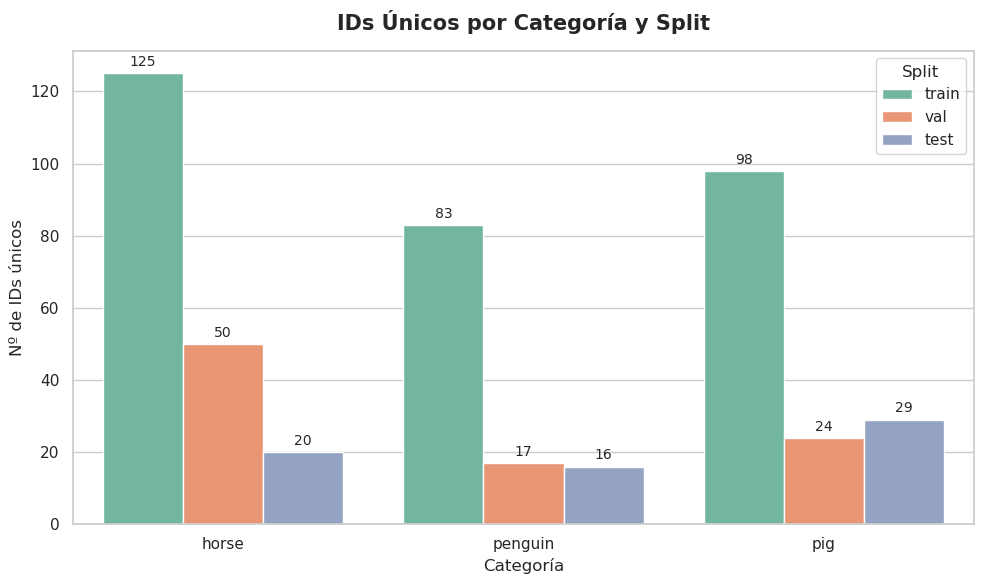

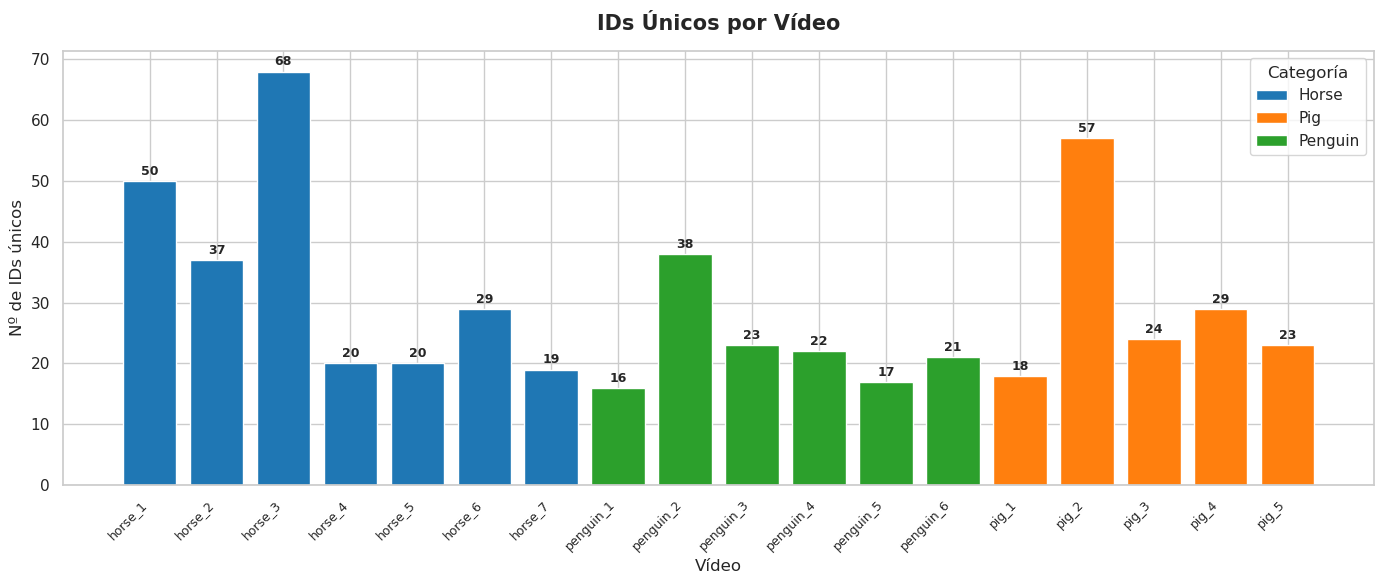

In [ ]:
split_csv = os.path.join(ULTRALYTICS_DIR, "dataset_split.csv")

df_splits = pd.read_csv(split_csv)
video_to_split = dict(zip(df_splits["Video"], df_splits["Split"]))
video_to_category = dict(zip(df_splits["Video"], df_splits["Category"]))

registros = []  

categories = [
    d for d in os.listdir(DATASET_DIR) 
    if os.path.isdir(os.path.join(DATASET_DIR, d))
]

for category in sorted(categories):
    gt_dir = os.path.join(DATASET_DIR, category, "gt")
    
    if not os.path.exists(gt_dir):
        continue
        
    rutas_txt = glob.glob(os.path.join(gt_dir, "*.txt"))
    
    for gt_file in sorted(rutas_txt):
        base_name = os.path.basename(gt_file)         
        video_name = base_name.replace("_gt.txt", "")   
        
        split = video_to_split.get(video_name, "desconocido")

        with open(gt_file, "r") as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) < 6:
                    continue
                frame_id = int(parts[0])
                obj_id = int(parts[1])
                x, y, w, h = float(parts[2]), float(parts[3]), float(parts[4]), float(parts[5])
                cx = x + w / 2
                cy = y + h / 2
                registros.append({
                    "category": category,
                    "video": video_name,
                    "split": split,
                    "frame": frame_id,
                    "obj_id": obj_id,
                    "x": x, "y": y, "w": w, "h": h,
                    "cx": cx, "cy": cy,
                })

df = pd.DataFrame(registros)

df["global_obj_id"] = df["video"] + "_" + df["obj_id"].astype(str)

print(f"Total de anotaciones GT leídas: {len(df)}")
print(f"Videos encontrados: {df['video'].nunique()}")
print()

stats_video = (
    df.groupby(["split", "category", "video"])["obj_id"]
    .nunique()
    .reset_index()
    .rename(columns={"obj_id": "num_ids"})
)

stats_cat_split = (
    df.groupby(["split", "category"])["global_obj_id"]
    .nunique()
    .reset_index()
    .rename(columns={"global_obj_id": "num_ids"})
)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

split_order = ["train", "val", "test"]
cat_order = sorted(stats_cat_split["category"].unique())

bar_plot = sns.barplot(
    data=stats_cat_split,
    x="category", y="num_ids", hue="split",
    hue_order=split_order, order=cat_order,
    palette="Set2", ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

ax.set_title("IDs Únicos por Categoría y Split", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Categoría", fontsize=12)
ax.set_ylabel("Nº de IDs únicos", fontsize=12)
ax.legend(title="Split")
fig.tight_layout()

ruta_grafico1 = os.path.join(ANALYSIS_DIR, "ids_per_category_split.png")
fig.savefig(ruta_grafico1, dpi=200)

fig, ax = plt.subplots(figsize=(14, 6))

stats_video_sorted = stats_video.sort_values(["category", "video"])

colors = [CATEGORY_COLORS.get(cat, "gray") for cat in stats_video_sorted["category"]]

bars = ax.bar(range(len(stats_video_sorted)), stats_video_sorted["num_ids"], color=colors, edgecolor="white")
ax.set_xticks(range(len(stats_video_sorted)))
ax.set_xticklabels(stats_video_sorted["video"], rotation=45, ha="right", fontsize=9)

for bar, val in zip(bars, stats_video_sorted["num_ids"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=9, fontweight="bold")

legend_elements = [Patch(facecolor=c, label=cat.capitalize()) for cat, c in CATEGORY_COLORS.items()]
ax.legend(handles=legend_elements, title="Categoría", loc="upper right")

ax.set_title("IDs Únicos por Vídeo", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Vídeo", fontsize=12)
ax.set_ylabel("Nº de IDs únicos", fontsize=12)
fig.tight_layout()

ruta_grafico2 = os.path.join(ANALYSIS_DIR, "ids_per_video.png")
fig.savefig(ruta_grafico2, dpi=200)


## Tracking con modelo

In [ ]:
split_df = pd.read_csv("ultralytics_dataset/dataset_split.csv")
test_videos = split_df[split_df['Split'] == 'test']

videos_a_evaluar = test_videos.groupby('Category').first().reset_index()

# Configuraciones de tracking
tracking_configs = {
    "ByteTrack 1": {
        "conf": 0.3,
        "iou": 0.5,
        "persist": True,
        "tracker": "bytetrack.yaml",
        "save": True,
        "verbose": False,
    },
    "ByteTrack 2": {
        "conf": 0.15,
        "iou": 0.65,
        "persist": True,
        "tracker": "bytetrack.yaml",
        "save": True,
        "verbose": False,
    }
}

class_names = yolom.names if hasattr(yolom, 'names') and yolom.names else {0: "pig", 1: "penguin", 2: "horse"}

# Mapeo de YOLO IDs (0, 1, 2) a IDs de AnimalTrack GT (8, 7, 6)
yolo_to_gt_cls = {
    0: 8,  # pig -> 8
    1: 7,  # penguin -> 7
    2: 6   # horse -> 6
}

metricas_a_mostrar = [
    'idf1', 'idp', 'idr',
    'mostly_tracked', 'mostly_lost',
    'num_switches',
    'mota',
    'num_unique_objects'
]

formato = {
    'idf1': '{:.2f}%'.format,
    'idp': '{:.2f}%'.format,
    'idr': '{:.2f}%'.format,
    'mostly_tracked': '{:.2f}%'.format,
    'mostly_lost': '{:.2f}%'.format,
    'mota': '{:.2f}%'.format,
    'num_unique_objects': '{:d}'.format
}

# Iterar sobre cada vídeo de test (uno por categoría)
for _, row in videos_a_evaluar.iterrows():
    category = row['Category']
    video_name = row['Video']
    
    VIDEO_PATH = f"{DATASET_DIR}/{category}/videos/{video_name}.mp4"
    GT_FILE = f"{DATASET_DIR}/{category}/gt/{video_name}_gt.txt"
    
    print(f"\n{'#'*70}")
    print(f"  ANIMAL: {category.upper()} | Vídeo: {video_name}")
    print(f"{'#'*70}")
    
    # Leer el Ground Truth de este vídeo
    gt = pd.read_csv(GT_FILE, header=None,
                     names=['frame', 'id', 'x', 'y', 'w', 'h', 'conf', 'class', 'vis'])
    
    # Evaluar cada configuración de tracker sobre este vídeo
    for config_name, config in tracking_configs.items():
        print(f"\n  =======================================================")
        print(f"   CONFIGURACIÓN: {config_name}")
        print(f"  =======================================================")
        
        # Inicializar acumuladores por clase
        accs_by_class = {cls_id: mm.MOTAccumulator(auto_id=True) for cls_id in class_names.keys()}
        hota_gt_ids_by_class = {cls_id: [] for cls_id in class_names.keys()}
        hota_pred_ids_by_class = {cls_id: [] for cls_id in class_names.keys()}
        hota_iou_by_class = {cls_id: [] for cls_id in class_names.keys()}
        
        # Inferir y rastrear
        resultados = yolom.track(source=VIDEO_PATH, **config)
        
        frame_idx = 1
        for frame_res in resultados:
            gt_frame = gt[gt['frame'] == frame_idx]
            
            pred_ids_all = []
            pred_boxes_all = []
            pred_classes_all = []
            
            if frame_res.boxes is not None and frame_res.boxes.id is not None:
                boxes_xyxy = frame_res.boxes.xyxy.cpu().numpy()
                pred_ids_all = frame_res.boxes.id.int().cpu().tolist()
                pred_classes_all = frame_res.boxes.cls.int().cpu().tolist()
                
                for box in boxes_xyxy:
                    x1, y1, x2, y2 = box
                    w, h = x2 - x1, y2 - y1
                    pred_boxes_all.append([x1, y1, w, h])
                    
            pred_boxes_all = np.array(pred_boxes_all) if len(pred_boxes_all) > 0 else np.empty((0, 4))
            
            for cls_id in class_names.keys():
                gt_cls_id = yolo_to_gt_cls.get(cls_id, cls_id)
                gt_class_frame = gt_frame[gt_frame['class'] == gt_cls_id]
                
                if len(gt_class_frame) == 0 and len(gt_frame[gt_frame['class'] == cls_id]) > 0:
                    gt_class_frame = gt_frame[gt_frame['class'] == cls_id]
                    
                gt_ids_c = gt_class_frame['id'].values
                
                if len(gt_ids_c) > 0:
                    gt_boxes_c = np.c_[gt_class_frame['x'].values, gt_class_frame['y'].values,
                                       gt_class_frame['w'].values, gt_class_frame['h'].values]
                else:
                    gt_boxes_c = np.empty((0, 4))
                    
                pred_ids_c = []
                pred_boxes_c = []
                for idx, pred_cls in enumerate(pred_classes_all):
                    if pred_cls == cls_id:
                        pred_ids_c.append(pred_ids_all[idx])
                        pred_boxes_c.append(pred_boxes_all[idx])
                        
                pred_boxes_c = np.array(pred_boxes_c) if len(pred_boxes_c) > 0 else np.empty((0, 4))
                
                if len(gt_ids_c) > 0 or len(pred_ids_c) > 0:
                    dist_matrix_c = mm.distances.iou_matrix(gt_boxes_c, pred_boxes_c, max_iou=0.5)
                    
                    accs_by_class[cls_id].update(gt_ids_c, pred_ids_c, dist_matrix_c)
                    
                    d_mat_c = np.array(dist_matrix_c, dtype=float)
                    iou_mat_c = 1.0 - d_mat_c
                    iou_mat_c[np.isnan(iou_mat_c)] = 0.0
                    
                    hota_gt_ids_by_class[cls_id].append(np.array(gt_ids_c, dtype=int))
                    hota_pred_ids_by_class[cls_id].append(np.array(pred_ids_c, dtype=int))
                    hota_iou_by_class[cls_id].append(iou_mat_c)
                else:
                    hota_gt_ids_by_class[cls_id].append(np.array([], dtype=int))
                    hota_pred_ids_by_class[cls_id].append(np.array([], dtype=int))
                    hota_iou_by_class[cls_id].append(np.empty((0, 0), dtype=float))
                    
            frame_idx += 1

        # Mostrar métricas solo para la clase relevante de este vídeo
        mh = mm.metrics.create()
        
        for cls_id, cls_name in class_names.items():
            acc_c = accs_by_class[cls_id]
            
            if len(acc_c.events) > 0:
                summary_c = mh.compute(acc_c, metrics=metricas_a_mostrar, name=cls_name)
                num_objs = summary_c['num_unique_objects'].iloc[0]
                
                if num_objs == 0:
                    continue  # Saltar clases sin GT (solo falsas detecciones)
                
                summary_c['mostly_tracked'] = (summary_c['mostly_tracked'] / num_objs) * 100
                summary_c['mostly_lost'] = (summary_c['mostly_lost'] / num_objs) * 100
                    
                for m in ['idf1', 'idp', 'idr', 'mota']:
                    summary_c[m] = summary_c[m] * 100
                    
                print(f"\n   --- MÉTRICAS TRADICIONALES ({cls_name.upper()}) ---")
                print(mm.io.render_summary(summary_c, formatters=formato, namemap={
                    'idf1': 'IDF1', 'idp': 'IDP', 'idr': 'IDR',
                    'mostly_tracked': 'MT (%)', 'mostly_lost': 'ML (%)',
                    'num_switches': 'IDSW', 'mota': 'MOTA',
                    'num_unique_objects': 'GT_Objs'
                }))
            else:
                continue  # Saltar clases sin eventos
        
            # HOTA
            gt_ids_hota = hota_gt_ids_by_class[cls_id]
            pred_ids_hota = hota_pred_ids_by_class[cls_id]
            iou_hota = hota_iou_by_class[cls_id]
            
            has_gt = any(len(x) > 0 for x in gt_ids_hota)
            if has_gt:
                resultados_hota = compute_hota_metrics(
                    gt_ids=gt_ids_hota,
                    tracker_ids=pred_ids_hota,
                    similarity_scores=iou_hota
                )
                print(f"\n   --- MÉTRICAS AVANZADAS ({cls_name.upper()}) ---")
                print(f"   HOTA: {resultados_hota['HOTA'] * 100:.2f}%")
                print(f"   DetA: {resultados_hota['DetA'] * 100:.2f}%")
                print(f"   AssA: {resultados_hota['AssA'] * 100:.2f}%")



######################################################################
  ANIMAL: HORSE | Vídeo: horse_4
######################################################################

   CONFIGURACIÓN: ByteTrack 1
WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /home/ainara/unileon/cuatri2/reconocimiento/runs/detect/predict

   --- MÉTRICAS TRADICIONALES (HORSE) ---
        IDF1    IDP    IDR MT (%) ML (%)  IDSW   MOTA GT_Objs
horse 33.91% 92.81% 20.75%  0.00% 60.00%     9 21.79%      20

   

In [ ]:
videos_por_clase = {
    "horse": "AnimalTrack/horse/videos/horse_4.mp4",
    "pig": "AnimalTrack/pig/videos/pig_4.mp4",
    "penguin": "AnimalTrack/penguin/videos/penguin_1.mp4"
}

# Ejecutar tracking y visualizar para cada clase
for clase, video_path in videos_por_clase.items():
    results = yolom.track(source=video_path, **tracking_configs["ByteTrack 1"])
    out_path = os.path.join(results[0].save_dir, os.path.basename(video_path))
    display(Video(out_path, embed=True, width=600))


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /home/ainara/unileon/cuatri2/reconocimiento/runs/detect/track2


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /home/ainara/unileon/cuatri2/reconocimiento/runs/detect/track2


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /home/ainara/unileon/cuatri2/reconocimiento/runs/detect/track2
